In [1625]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import destroy, basis, ket2dm, smesolve, sigmam
# number of modes
N = 2

# Destroy operator
a = destroy(N)

#Hamiltonian
H = a.dag() * a # Hamiltonian (not evolving)

# Initial excited state
psi0 = basis(N, 1) # Initial state |1>
rho0 = ket2dm(psi0)  # Convert to density matrix

#dissipative terms
gamma_relax=1
T_1= 1/gamma_relax
k=1

#efficiency terms
measurement_rate = 100 #high=less noise - low=high noise
#dephasing_rate = 0
#measurement_efficiency = (measurement_rate)/(measurement_rate + dephasing_rate)

#collapse operators 
c_ops = []
c_ops.append(np.sqrt(k) * sigmam())#c1= sqrt(kappa)*signam_- ------excitation
c_ops.append(np.sqrt(gamma_relax) * a)#c2= sqrt(gamma)*a -----decay (a=sigmap())
#c_ops.append(np.sqrt(dephasing_rate)* sigmaz())

# Stochastic collapse operators -- IN REALITY ACTS AS MEASURMENT OPERATOR -- 
sc_ops = []
sc_ops.append(np.sqrt(measurement_rate)*sigmaz()) 

#Time scale
dt=1/1000
tmax=50
t = np.arange(0, tmax, dt)

# Time evolution
result = smesolve(
    H*0, 
    rho0, 
    t, 
    c_ops, 
    sc_ops, 
    e_ops=[a.dag()*a], 
    store_measurement=True,
    ntraj=1,
    nsubsteps=400
    )

# Extract expectation values (noisy signal)
expec_signal= result.expect[0] # Using sigmaz() expectation as the signal
noisy_signal = result.measurement[0]  * (-1)


Total run time:  96.74s


In [1626]:
# Define the window size in number of points
window_size_points = 10

# Calculate the integration window width
window_width = t[window_size_points] - t[0]

# Perform the integration
clean_signal = []
for i in range(0, len(noisy_signal), window_size_points):
    if i + window_size_points <= len(noisy_signal):
        window_average = np.mean(noisy_signal[i:i + window_size_points])
        integrated_value = window_average * window_width
        clean_signal.append(integrated_value)

# Create a new time array for the integrated signal
t_integrated = t[::window_size_points][:len(clean_signal)]

# Thresholding to create a binary signal
threshold = np.mean(clean_signal)  # Choosing the mean as a threshold
binary_signal = np.where(clean_signal > threshold, 1, 0)

/Users/filippo/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


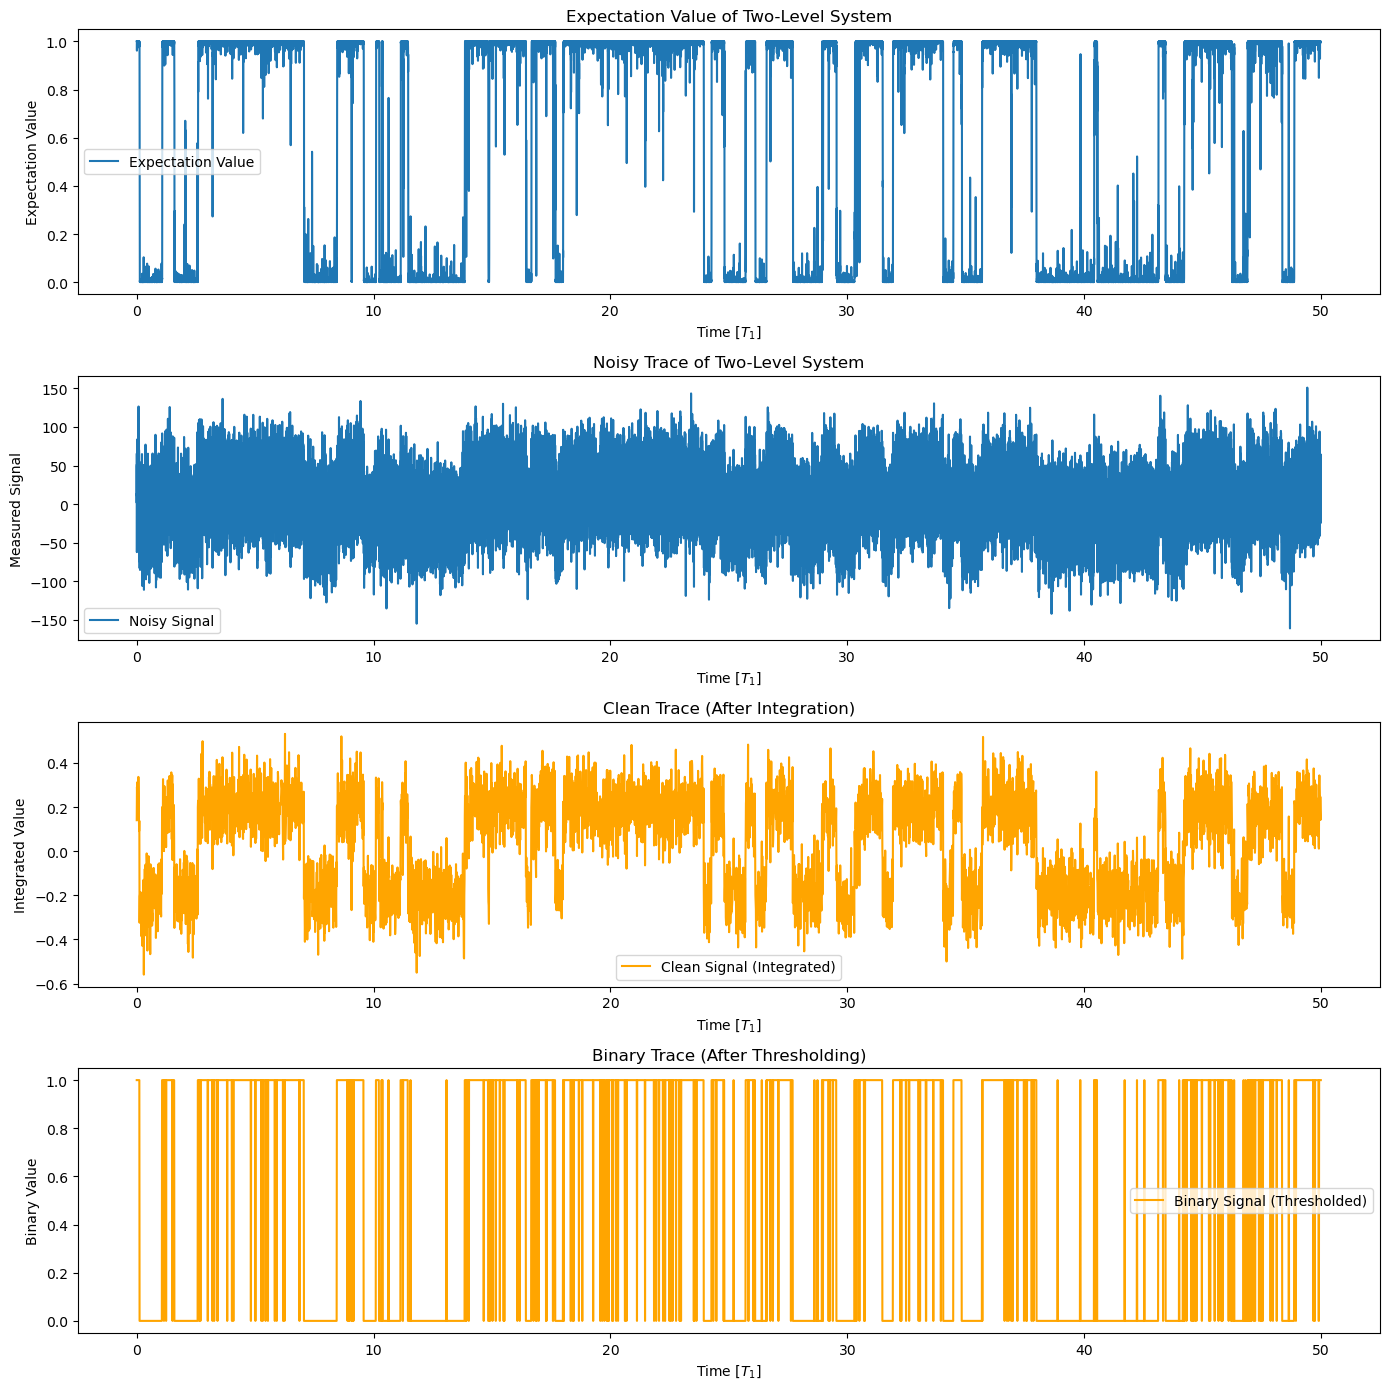

In [1627]:
# Plotting the results
plt.figure(figsize=(14, 14))

plt.subplot(4, 1, 1)
plt.plot(t, expec_signal, label='Expectation Value')
plt.title('Expectation Value of Two-Level System')
plt.xlabel('Time $[T_1]$')
plt.ylabel('Expectation Value')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.title('Noisy Trace of Two-Level System')
plt.xlabel('Time $[T_1]$')
plt.ylabel('Measured Signal')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t_integrated, clean_signal, label='Clean Signal (Integrated)', color='orange')
plt.title('Clean Trace (After Integration)')
plt.xlabel('Time $[T_1]$')
plt.ylabel('Integrated Value')
plt.legend()

plt.subplot(4,1,4)
plt.plot(t_integrated, binary_signal, label='Binary Signal (Thresholded)', color='orange')
plt.title('Binary Trace (After Thresholding)')
plt.xlabel('Time $[T_1]$')
plt.ylabel('Binary Value')
plt.legend()

plt.tight_layout()
plt.savefig("tracenoise.pdf",bbox_inches='tight')
plt.show()

In [1492]:
def calculate_decay_times(states, times):
    decay_times = []
    n = len(states)
    i = 0
    while i < n:
        if states[i] == 1:
            start = i
            while i < n and states[i] == 1:
                i += 1
            end = i
            if end==len(times):
                break
                #end=end-1
            decay_time = times[end] - times[start]
            #if decay_time > 0:
            decay_times.append(decay_time)
        i += 1

    return decay_times

In [1530]:
#Experiment with different integration window sizes
window_sizes_points = np.arange(1, 2001,1)  # Example range of window sizes in points
window_sizes_time = (window_sizes_points * (t[1] - t[0]))  # Convert points to time
average_decay_times = []

for window_size_points in window_sizes_points:
    # Calculate the integration window width in time
    window_width = t[window_size_points] - t[0]

    # Perform the integration
    integrated_signal = []
    for i in range(0, len(noisy_signal), window_size_points):
        if i + window_size_points <= len(noisy_signal):
            window_average = np.mean(noisy_signal[i:i + window_size_points])
            integrated_value = window_average * window_width
            integrated_signal.append(integrated_value)

    # Create a new time array for the integrated signal
    t_integrated = t[::window_size_points][:len(integrated_signal)]

    # Convert the integrated signal to a binary signal
    threshold = np.mean(integrated_signal)
    binary_signal = np.where(integrated_signal > threshold, 1, 0)

    # Calculate decay times and their average
    decay_times = calculate_decay_times(binary_signal, t_integrated)
    average_decay_time = np.mean(decay_times)
    average_decay_times.append(average_decay_time)

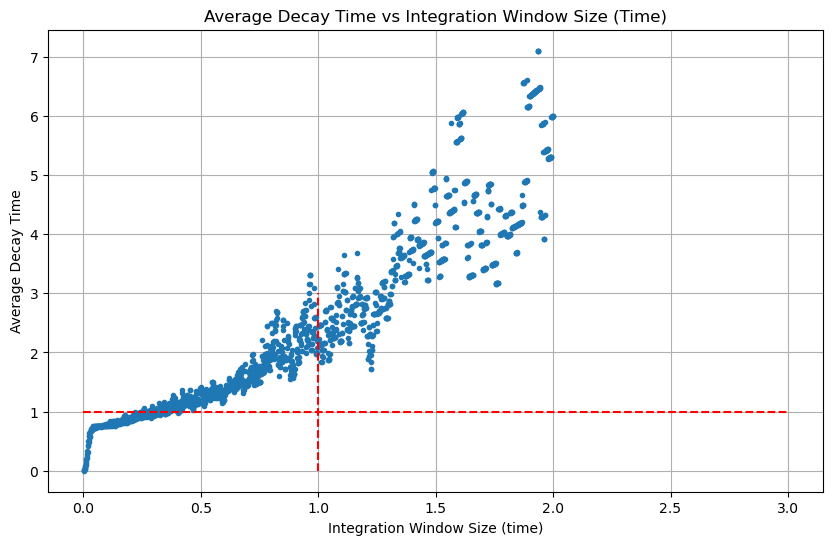

In [1531]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(window_sizes_time, average_decay_times, ".")
plt.hlines(1,0,3,linestyle='dashed',color='red')
plt.vlines(1,0,3,linestyle='dashed',color='red')
plt.title('Average Decay Time vs Integration Window Size (Time)')
plt.xlabel('Integration Window Size (time)')
plt.ylabel('Average Decay Time')
plt.grid(True)
plt.show()

In [649]:
###Start cycle calculations - Over multiple experiments to get erro bars, and then sweep across 

In [1608]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import destroy, basis, ket2dm, smesolve, sigmam
# number of modes
N = 2

# Destroy operator
a = destroy(N)

#Hamiltonian
H = a.dag() * a # Hamiltonian (not evolving)

# Initial excited state
psi0 = basis(N, 1) # Initial state |1>
rho0 = ket2dm(psi0)  # Convert to density matrix

#dissipative terms
gamma_relax=1
T_1= 1/gamma_relax
k=1

#efficiency terms
measurement_rate = 60 #high=less noise - low=high noise
#dephasing_rate = 1
#measurement_efficiency = (measurement_rate)/(measurement_rate + dephasing_rate)

#collapse operators 
c_ops = []
c_ops.append(np.sqrt(k) * sigmam())#c1= sqrt(kappa)*signam_- ------excitation
c_ops.append(np.sqrt(gamma_relax) * a)#c2= sqrt(gamma)*a -----decay (a=sigmap())
#c_ops.append(np.sqrt(dephasing_rate)* sigmaz())

# Stochastic collapse operators -- IN REALITY ACTS AS MEASURMENT OPERATOR -- 
sc_ops = []
sc_ops.append(np.sqrt(measurement_rate)*sigmaz()) 

#Time scale
tmax=50
dt=1/1000
t = np.arange(0, tmax, dt)


In [1609]:
all_signals=[]
# Number of trajectories for averaging
n_experiments = 10

for _ in range(n_experiments):
    # Time evolution
    result = smesolve(
        H*0, 
        rho0, 
        t, 
        c_ops, 
        sc_ops, 
        e_ops=[a.dag()*a], 
        store_measurement=True,
        ntraj=1,
        nsubsteps=400
    )
    
    # Extract expectation values (noisy signal)
    noisy_signal = result.measurement[0]

    # Store noisy signals for each experiment
    all_signals.append(noisy_signal)


Total run time:  73.63s


KeyboardInterrupt: 

In [ ]:
import numpy as np

# Experiment with different integration window sizes
window_sizes_points = np.arange(1, 1001, 1)  # Example range of window sizes in points
window_sizes_time = (window_sizes_points * (t[1] - t[0]))  # Convert points to time
all_integrated_signals = {size: [] for size in window_sizes_points}

average_decay_times = []
std_decay_times = []

for window_size_points in window_sizes_points:
    # Calculate the integration window width in time
    window_width = t[window_size_points] - t[0]

    # Iterate through all noisy signals to perform the integration
    for noisy_signal in all_signals:
        integrated_signal = []  # This should be initialized inside the loop
        # Perform the integration
        for i in range(0, len(noisy_signal), window_size_points):
            if i + window_size_points <= len(noisy_signal):
                window_average = np.mean(noisy_signal[i:i + window_size_points])
                integrated_value = window_average * window_width
                integrated_signal.append(integrated_value)
        
        all_integrated_signals[window_size_points].append(integrated_signal)

    # Calculate the average and standard deviation of decay times
    all_decay_times = []
    for integrated_signal in all_integrated_signals[window_size_points]:
        t_integrated = t[::window_size_points][:len(integrated_signal)]
        
        # Convert the integrated signal to a binary signal
        threshold = np.mean(integrated_signal)
        binary_signal = np.where(integrated_signal > threshold, 1, 0)
        
        # Calculate decay times
        decay_times = calculate_decay_times(binary_signal, t_integrated)
        all_decay_times.append(np.mean(decay_times))
    
    average_decay_time = np.mean(all_decay_times)
    std_decay_time = np.std(all_decay_times)
    average_decay_times.append(average_decay_time)
    std_decay_times.append(std_decay_time)
    print(window_size_points)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


ValueError: 'x' and 'y' must have the same size

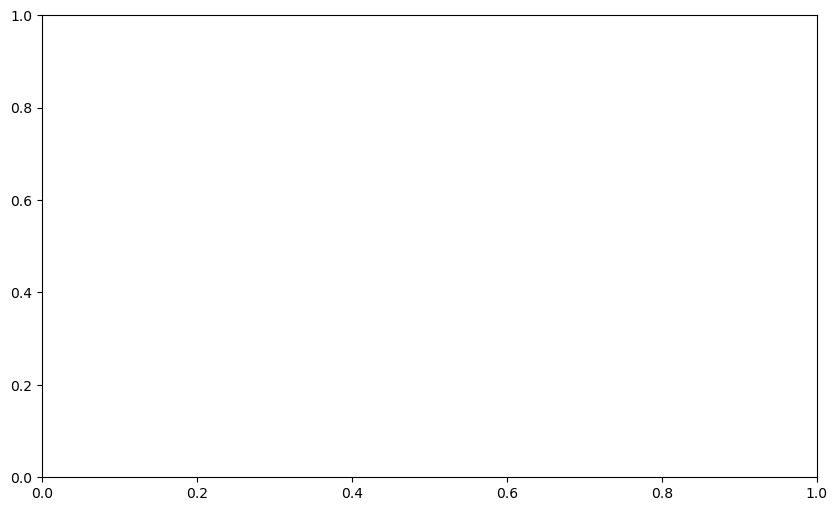

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(window_sizes_time, average_decay_times, yerr=std_decay_times, fmt='.', ecolor='blue', capsize=3)
plt.hlines(1, 0, max(window_sizes_time), linestyle='dashed', color='red')
plt.vlines(1, 0, max(average_decay_times), linestyle='dashed', color='red')
plt.title('Average Decay Time vs Integration Window Size (Time)')
plt.xlabel('Integration Window Size (time)')
plt.ylabel('Average Decay Time')
plt.xscale('log')
plt.grid(True)
plt.show()

In [1628]:
import numpy as np
from qutip import basis, ket2dm, smesolve, destroy, sigmam, sigmaz

# Define constants and operators
efficiencies = np.array([1000,600, 100, 20, 1])  # Efficiencies
N = 2  # number of modes
a = destroy(N)
H = a.dag() * a  # Hamiltonian (not evolving)
psi0 = basis(N, 1)  # Initial state |1>
rho0 = ket2dm(psi0)  # Convert to density matrix
gamma_relax = 1
T_1 = 1 / gamma_relax
k = 1
c_ops = [np.sqrt(k) * sigmam(), np.sqrt(gamma_relax) * a]  # collapse operators

#Time scale
tmax=50
dt=1/2000
t = np.arange(0, tmax, dt)

n_experiments = 20

# Prepare data storage
experiment_data = {eff: [] for eff in efficiencies}

for efficiency in efficiencies:
    sc_ops = [np.sqrt(efficiency) * sigmaz()]  # Scaled measurement operator by efficiency
    for _ in range(n_experiments):
        result = smesolve(H*0, rho0, t, c_ops, sc_ops, e_ops=[a.dag()*a], store_measurement=True, ntraj=1,nsubsteps=100)
        noisy_signal = result.measurement[0]  # Extract expectation values (noisy signal)
        experiment_data[efficiency].append(noisy_signal)


Total run time:  49.71s
Total run time:  48.98s
Total run time:  48.84s
Total run time:  48.90s
Total run time:  48.92s
Total run time:  48.83s
Total run time:  48.99s
Total run time:  48.80s
Total run time:  49.21s
Total run time:  49.04s
Total run time:  49.34s
Total run time:  49.28s
Total run time:  49.18s
Total run time:  49.06s
Total run time:  48.77s
Total run time:  48.74s
Total run time:  48.74s
Total run time:  48.80s
Total run time:  48.86s
Total run time:  48.93s
Total run time:  48.88s
Total run time:  48.67s
Total run time:  48.39s
Total run time:  48.67s
Total run time:  48.74s
Total run time:  48.67s
Total run time:  48.63s
Total run time:  48.70s
Total run time:  48.62s
Total run time:  48.76s
Total run time:  48.70s
Total run time:  48.69s
Total run time:  48.67s
Total run time:  48.79s
Total run time:  49.10s
Total run time:  48.75s
Total run time:  48.98s
Total run time:  48.55s
Total run time:  48.59s
Total run time:  48.76s
Total run time:  48.58s
Total run time: 

In [1611]:
# Define time-based window sizes
min_time = t[1] - t[0]  # minimum window size (difference between two time points)
max_time = 1  # maximum window size (total duration)
num_windows = 100  # Number of window sizes

window_sizes_time = np.logspace(np.log10(min_time), np.log10(max_time), num=num_windows)

In [1629]:
a

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 1.]
 [0. 0.]]

In [1612]:
# Analyze data with time-based windows
analysis_results = {eff: {'average': [], 'std': []} for eff in efficiencies}

for efficiency in experiment_data:
    all_integrated_signals = {size: [] for size in window_sizes_time}
    for noisy_signal in experiment_data[efficiency]:
        signal_time_length = t[-1] - t[0]
        for window_size in window_sizes_time:
            integrated_signal = []
            step_size = int(round(window_size / min_time))  # Calculate the number of points in each window
            for i in range(0, len(noisy_signal), step_size):
                if i + step_size <= len(noisy_signal):
                    window_average = np.mean(noisy_signal[i:i + step_size])
                    integrated_signal.append(window_average * window_size)
            all_integrated_signals[window_size].append(integrated_signal)

    for window_size in window_sizes_time:
        all_decay_times = []
        for integrated_signal in all_integrated_signals[window_size]:
            t_integrated = t[::len(t) // len(integrated_signal)]
            threshold = np.mean(integrated_signal)
            binary_signal = np.where(integrated_signal > threshold, 1, 0)
            decay_times = calculate_decay_times(binary_signal, t_integrated)
            all_decay_times.append(np.mean(decay_times))

        average_decay_time = np.mean(all_decay_times)
        std_decay_time = np.std(all_decay_times)/np.sqrt(n_experiments-1)
        analysis_results[efficiency]['average'].append(average_decay_time)
        analysis_results[efficiency]['std'].append(std_decay_time)


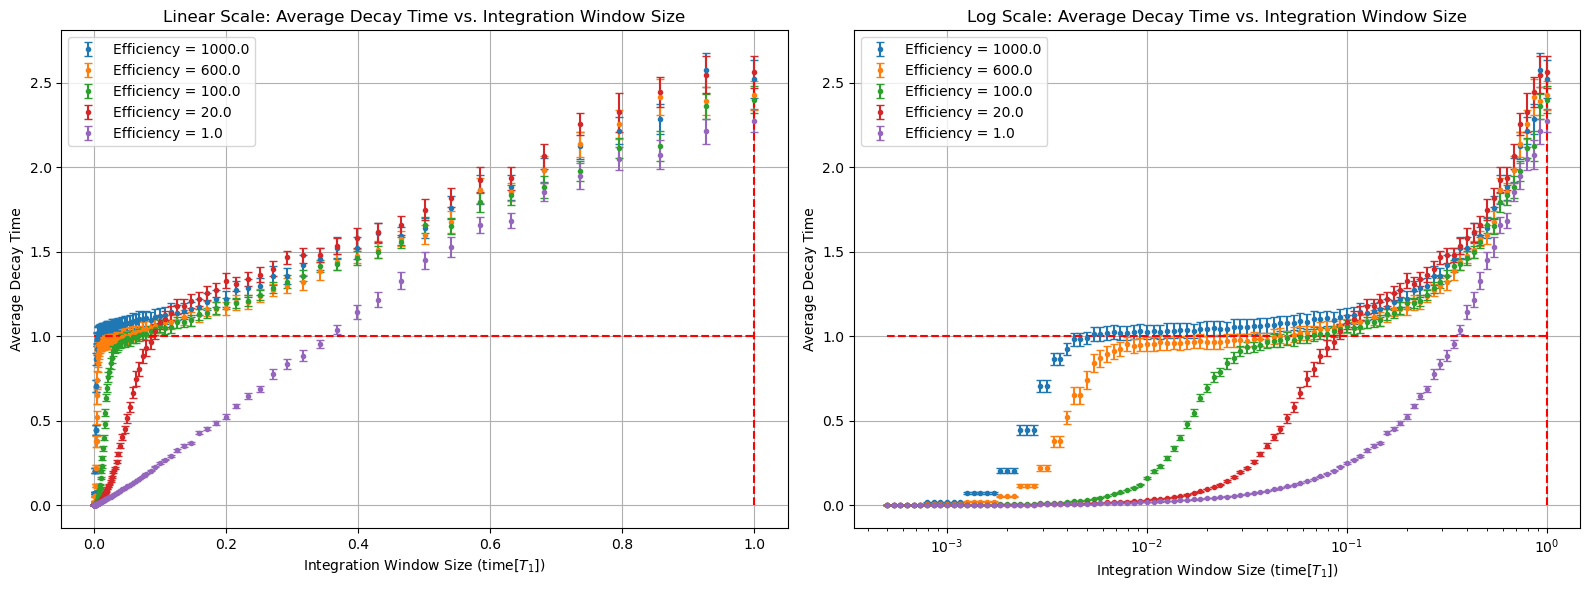

In [1614]:
import matplotlib.pyplot as plt

# Set up a figure with two subplots (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# Loop through each efficiency to plot data on both subplots
for efficiency in efficiencies:
    avg_decay_times = analysis_results[efficiency]['average']
    std_decay_times = analysis_results[efficiency]['std']
    
    # Plot on the first subplot (Linear scale)
    ax1.errorbar(window_sizes_time, avg_decay_times, yerr=std_decay_times, fmt='.', capsize=3, label=f'Efficiency = {efficiency:.1f}')
    ax1.set_title('Linear Scale: Average Decay Time vs. Integration Window Size')
    ax1.set_xlabel('Integration Window Size (time[$T_1$])')
    ax1.set_ylabel('Average Decay Time [$T_1$]')
    ax1.legend()
    ax1.grid(True)
    
    # Plot on the second subplot (Logarithmic scale)
    ax2.errorbar(window_sizes_time, avg_decay_times, yerr=std_decay_times, fmt='.', capsize=3, label=f'Efficiency = {efficiency:.1f}')
    ax2.set_xscale('log')
    ax2.set_title('Log Scale: Average Decay Time vs. Integration Window Size')
    ax2.set_xlabel('Integration Window Size (time[$T_1$])')
    ax2.set_ylabel('Average Decay Time [$T_1$]')
    ax2.legend()
    ax2.grid(True)

# Adding reference lines for context
ax1.hlines(1, window_sizes_time[0], window_sizes_time[-1], linestyle='dashed', color='red')
ax1.vlines(1, 0, max(max(d['average']) for d in analysis_results.values()), linestyle='dashed', color='red')
ax2.hlines(1, window_sizes_time[0], window_sizes_time[-1], linestyle='dashed', color='red')
ax2.vlines(1, 0, max(max(d['average']) for d in analysis_results.values()), linestyle='dashed', color='red')

# Adjust layout to prevent overlap and ensure clear presentation
plt.tight_layout()
plt.show()


In [1617]:
window_sizes_points = np.arange(1, 1001, 1)

# Analyze data
analysis_results = {eff: {'average': [], 'std': []} for eff in efficiencies}

for efficiency in experiment_data:
    all_integrated_signals = {size: [] for size in window_sizes_points}
    for noisy_signal in experiment_data[efficiency]:
        for window_size_points in window_sizes_points:
            window_width = t[window_size_points] - t[0]
            integrated_signal = []
            for i in range(0, len(noisy_signal), window_size_points):
                if i + window_size_points <= len(noisy_signal):
                    window_average = np.mean(noisy_signal[i:i + window_size_points])
                    integrated_signal.append(window_average * window_width)
            all_integrated_signals[window_size_points].append(integrated_signal)
    
    for window_size_points in window_sizes_points:
        all_decay_times = []
        for integrated_signal in all_integrated_signals[window_size_points]:
            t_integrated = t[::window_size_points][:len(integrated_signal)]
            threshold = np.mean(integrated_signal)
            binary_signal = np.where(integrated_signal > threshold, 1, 0)
            decay_times = calculate_decay_times(binary_signal, t_integrated)
            all_decay_times.append(np.mean(decay_times))
        
        average_decay_time = np.mean(all_decay_times)
        std_decay_time = np.std(all_decay_times)/np.sqrt(n_experiments)
        analysis_results[efficiency]['average'].append(average_decay_time)
        analysis_results[efficiency]['std'].append(std_decay_time)


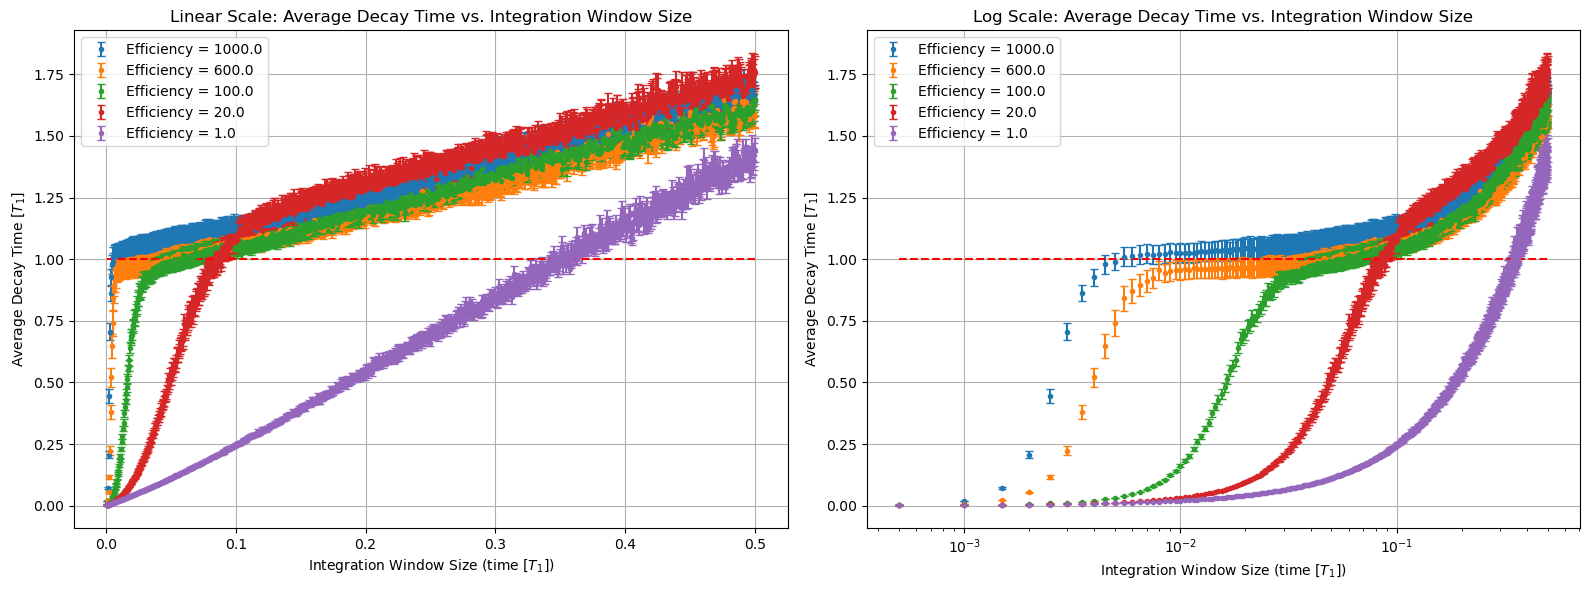

In [1623]:
import matplotlib.pyplot as plt

# Set up a figure with two subplots (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loop through each efficiency to plot data on both subplots
for efficiency in efficiencies:
    avg_decay_times = analysis_results[efficiency]['average']
    std_decay_times = analysis_results[efficiency]['std']
    
    # Plot on the first subplot (Linear scale)
    ax1.errorbar(window_sizes_time, avg_decay_times, yerr=std_decay_times, fmt='.', capsize=3, label=f'Efficiency = {efficiency:.1f}')
    ax1.set_title('Linear Scale: Average Decay Time vs. Integration Window Size')
    ax1.set_xlabel('Integration Window Size (time [$T_1$])')
    ax1.set_ylabel('Average Decay Time [$T_1$]')
    ax1.legend()
    ax1.grid(True)
    
    # Plot on the second subplot (Logarithmic scale)
    ax2.errorbar(window_sizes_time, avg_decay_times, yerr=std_decay_times, fmt='.', capsize=3, label=f'Efficiency = {efficiency:.1f}')
    ax2.set_xscale('log')
    ax2.set_title('Log Scale: Average Decay Time vs. Integration Window Size')
    ax2.set_xlabel('Integration Window Size (time [$T_1$])')
    ax2.set_ylabel('Average Decay Time [$T_1$]')
    ax2.legend()
    ax2.grid(True)

# Adding reference lines for context in both plots
ax1.hlines(1, window_sizes_time[0], window_sizes_time[-1], linestyle='dashed', color='red')
ax2.hlines(1, window_sizes_time[0], window_sizes_time[-1], linestyle='dashed', color='red')

# Adjust layout to prevent overlap and ensure clear presentation
plt.tight_layout()
plt.savefig("efficiencies.pdf",bbox_inches='tight')
plt.show()


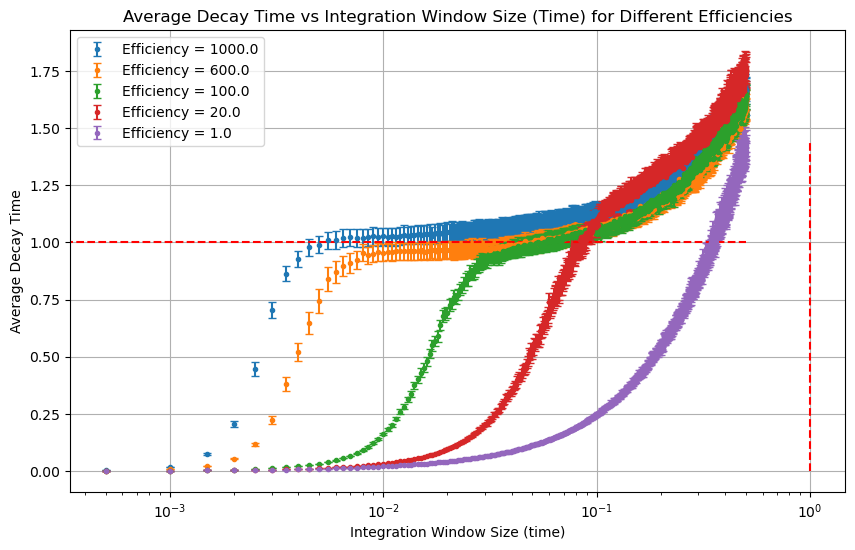

In [1620]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for efficiency in efficiencies:
    window_sizes_time = (window_sizes_points * (t[1] - t[0]))
    avg_decay_times = analysis_results[efficiency]['average']
    std_decay_times = analysis_results[efficiency]['std']
    plt.errorbar(window_sizes_time, avg_decay_times, yerr=std_decay_times, fmt='.', capsize=3, label=f'Efficiency = {efficiency:.1f}')

plt.hlines(1, 0, max(window_sizes_time), linestyle='dashed', color='red')
plt.vlines(1, 0, max(avg_decay_times), linestyle='dashed', color='red')
#plt.yscale('log')
plt.xscale('log')

plt.title('Average Decay Time vs Integration Window Size (Time) for Different Efficiencies')
plt.xlabel('Integration Window Size (time)')
plt.ylabel('Average Decay Time')
plt.legend()
plt.grid(True)